# **Ola Bike Ride Request Forecast using ML**

## **Importing the Dependencies**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor



## **Data Collection & Processing**

In [ ]:
df = pd.read_csv(r"ola.csv")

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.shape

(10886, 12)

## **Handling with Missing Values**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


## **Feature Engineering**

In [ ]:
parts = df['datetime'].str.split(" ")
print(parts)

0        [2011-01-01, 00:00:00]
1        [2011-01-01, 01:00:00]
2        [2011-01-01, 02:00:00]
3        [2011-01-01, 03:00:00]
4        [2011-01-01, 04:00:00]
                  ...          
10881    [2012-12-19, 19:00:00]
10882    [2012-12-19, 20:00:00]
10883    [2012-12-19, 21:00:00]
10884    [2012-12-19, 22:00:00]
10885    [2012-12-19, 23:00:00]
Name: datetime, Length: 10886, dtype: object


In [ ]:
df['date'] = df['datetime'].str.split(' ').str[0]
df["time"] = df['datetime'].str.split(' ').str[1].str[:2].astype(int)



In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,time
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,4


In [ ]:
parts = df['date'].str.split('-',n=3, expand= True)
print(parts)

          0   1   2
0      2011  01  01
1      2011  01  01
2      2011  01  01
3      2011  01  01
4      2011  01  01
...     ...  ..  ..
10881  2012  12  19
10882  2012  12  19
10883  2012  12  19
10884  2012  12  19
10885  2012  12  19

[10886 rows x 3 columns]


In [ ]:
df['year'] = parts[0].astype('int')
df['month'] = parts[1].astype('int')
df['day'] = parts[2].astype('int')

In [ ]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,time,year,month,day
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1,0,2011,1,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1,1,2011,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1,2,2011,1,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1,3,2011,1,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1,4,2011,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,19,19,2012,12,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,19,20,2012,12,19
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,19,21,2012,12,19
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,19,22,2012,12,19


In [ ]:
def am_or_pm(x):
  if x > 11:
    return 1
  else:
    return 0

df['am_or_pm']=df['time'].apply(am_or_pm)
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,time,year,month,day,am_or_pm
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,0,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,2011,1,1,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,2,2011,1,1,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,3,2011,1,1,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,4,2011,1,1,0


# **Dropping the unwanted columns**

In [ ]:
df.drop(['datetime','date'],axis = 1, inplace = True)

In [ ]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,time,year,month,day,am_or_pm
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,2011,1,1,0
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,2011,1,1,0
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,2011,1,1,0
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,2011,1,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   casual      10886 non-null  int64  
 9   registered  10886 non-null  int64  
 10  count       10886 non-null  int64  
 11  time        10886 non-null  int64  
 12  year        10886 non-null  int64  
 13  month       10886 non-null  int64  
 14  day         10886 non-null  int64  
 15  am_or_pm    10886 non-null  int64  
dtypes: float64(3), int64(13)
memory usage: 1.3 MB


## **EDA**

In [ ]:
df.corr()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,time,year,month,day,am_or_pm
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439,-0.006546,-0.004797,0.971524,0.001729,-0.005958
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393,-0.000354,0.012021,0.001731,-0.015877,-0.000362
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594,0.002780,-0.002482,-0.003394,0.009829,0.002465
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655,-0.022740,-0.012548,0.012144,-0.007890,-0.028592
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454,0.145430,0.061226,0.257589,0.015551,0.190038
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784,0.140343,0.058540,0.264173,0.011866,0.183401
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371,-0.278011,-0.078606,0.204537,-0.011335,-0.358050
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369,0.146631,-0.015221,-0.150192,0.036157,0.178367
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414,0.302045,0.145241,0.092722,0.014109,0.381691
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948,0.380540,0.264265,0.169451,0.019111,0.356006


<Axes: >

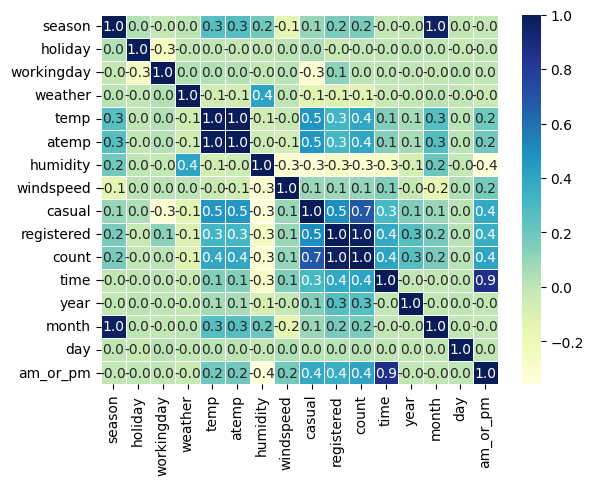

In [ ]:
sb.heatmap(df.corr(),cmap = 'YlGnBu', annot = True, fmt = '.1f', linewidths=0.5)


<function matplotlib.pyplot.show(close=None, block=None)>

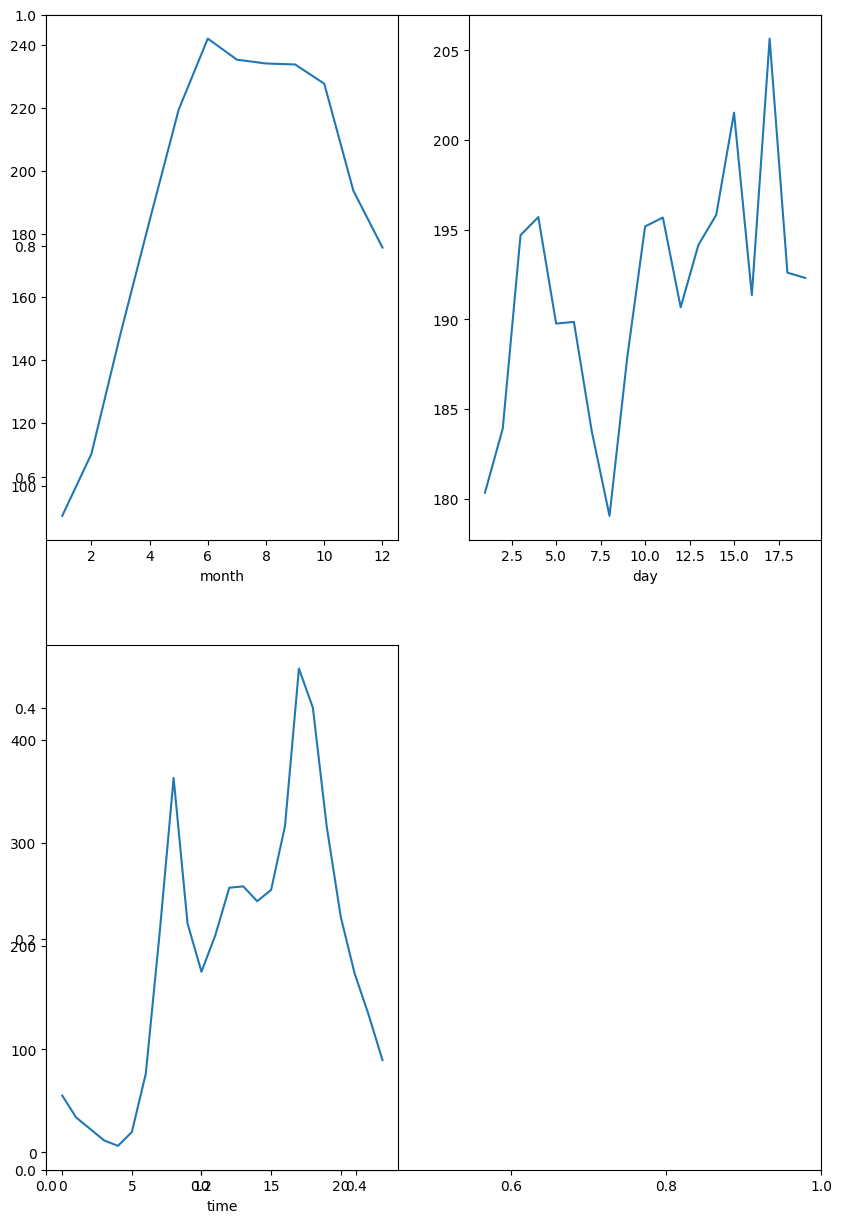

In [ ]:
features = ["month","day","time"]

plt.subplots(figsize=(10,15))

for i,col in enumerate(features):

  plt.subplot(2,2,i+1)
  df.groupby(col).mean()['count'].plot()

plt.show

From the above line plots we can confirm some real-life observations.

1.   There is no such pattern in the day-wise average of the ride requests.

2.   More ride requests in the working hours as compared to the non-working hours.

3. The average ride request count has dropped in the month of festivals that is after 7th month that is July that is due to more holidays in these days.



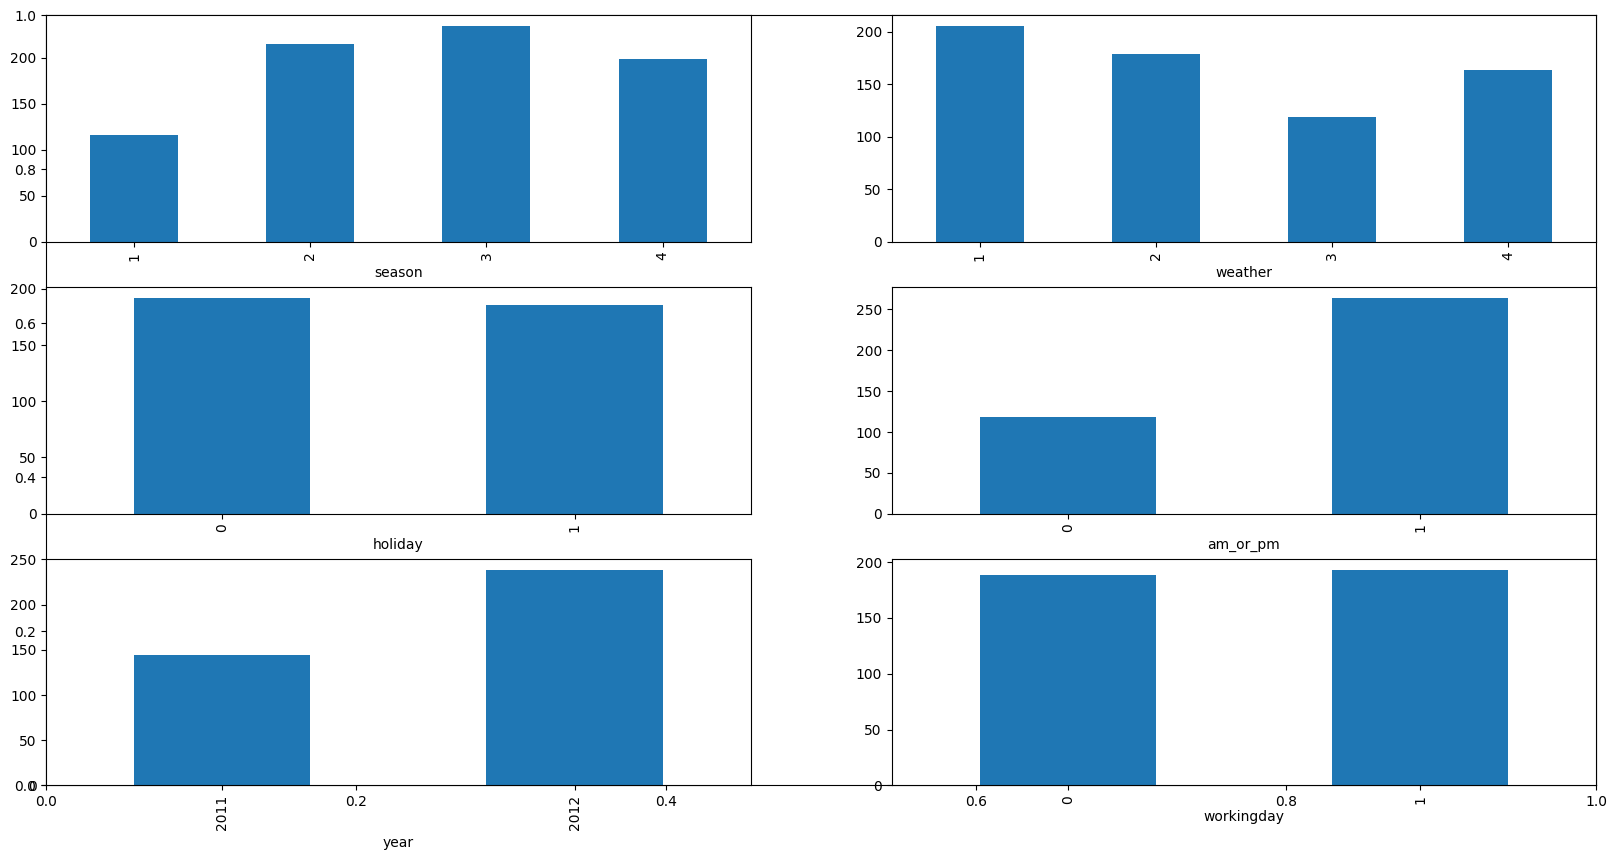

In [ ]:
features = ['season','weather','holiday','am_or_pm','year','workingday']

plt.subplots(figsize=(20,10))

for i,col in enumerate(features):

  plt.subplot(3,2,i+1)
  df.groupby(col).mean()['count'].plot.bar()

From the above bar plots we can confirm some real-life observations:

*   Ride request demand is high in the summer as well as season.
*   The third category was extreme weather conditions due to this people avoid taking bike rides and like to stay safe at home.
*   On holidays no college or offices are open due to this ride request demand is low.
*   More ride requests during working hours as compared to non-working hours.
*   Bike ride requests have increased significantly from year 2011 to the year 2012




## **Model Training**

In [ ]:
features = df.drop(['count'],axis=1)
target = df['count'].values

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(features,target,test_size=.2,random_state=2)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(8708, 15)
(2178, 15)


In [ ]:
scalar = StandardScaler()

X_train = scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error as mae
models = [LinearRegression(), XGBRegressor(), Lasso(),RandomForestRegressor(),Ridge()]

for i in range(5):
  models[i].fit(X_train,Y_train)

  print(f'{models[i]} : ')

  train_preds = models[i].predict(X_train)
  print('Training Error : ',mae(Y_train,train_preds))

  test_preds = models[i].predict(X_test)
  print('Validation Error :', mae(Y_test,test_preds))
  print()

LinearRegression() : 
Training Error :  6.744362634847391e-13
Validation Error : 6.564984246462259e-13

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...) : 
Training Error :  1.0778716802597046
Validation Error : 2.4848310947418213

Lasso() : 
Training Error :  0.9066885119719663
Validation Error : 0.9